### Importing dataset from Google Drive

### Findings

* 75,000 rows
* 4 columns:
  * sample_id → unique product ID
  * catalog_content → text (title + description + IPQ)
  * image_link → image URL
  * price → target variable

each catalog content has
*   Item Name
*   Value
*   Unit
  


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Exploratory Data Analysis

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re


# download images set
import os
import urllib
from pathlib import Path
from functools import partial
from tqdm import tqdm
import multiprocessing


# EfficientNet-B3
from tqdm import tqdm
from PIL import Image
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing import image_dataset_from_directory



from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from scipy.sparse import hstack, csr_matrix
import lightgbm as lgb
import pickle
import scipy.sparse

from lightgbm import early_stopping, log_evaluation
from sklearn.metrics import mean_squared_error
import scipy

In [ ]:
BASE_PATH = '/content/drive/MyDrive/Colab Notebooks/Price_Prediction/'
TRAIN_PATH = f'{BASE_PATH}dataset/train.csv'
TEST_PATH = f'{BASE_PATH}dataset/test.csv'

# Load data
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

df_processed = train_df.copy()
df_processed['log_price'] = np.log1p(train_df['price'])

### Basic Checks

In [ ]:
catalog_text = train_df.iloc[4,1]
print(catalog_text)

Item Name: kedem Sherry Cooking Wine, 12.7 Ounce - 12 per case.
Bullet Point: kedem Sherry Cooking Wine, 12.7 Ounce - 12 per case.
Value: 12.0
Unit: Count



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sample_id        75000 non-null  int64  
 1   catalog_content  75000 non-null  object 
 2   image_link       75000 non-null  object 
 3   price            75000 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 2.3+ MB
None
sample_id          0
catalog_content    0
image_link         0
price              0
dtype: int64
count    75000.000000
mean       908.886547
std        852.896151
min         32.000000
25%        251.000000
50%        643.000000
75%       1280.000000
max       7894.000000
Name: text_len, dtype: float64
count    75000.000000
mean        23.647654
std         33.376932
min          0.130000
25%          6.795000
50%         14.000000
75%         28.625000
max       2796.000000
Name: price, dtype: float64


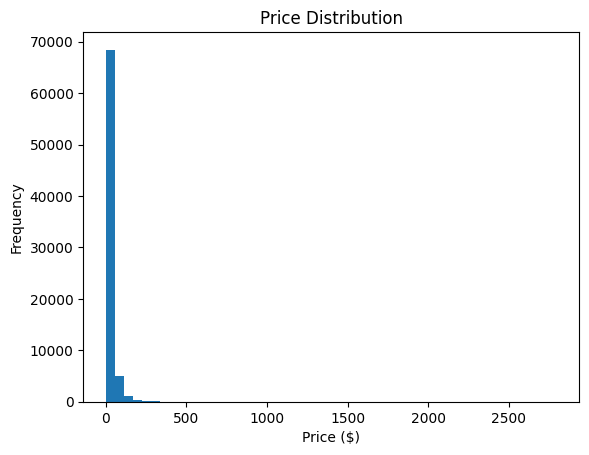

In [ ]:
# Basic checks
print(train_df.info())
print(train_df.isna().sum())

# Check for missing or empty text
train_df['text_len'] = train_df['catalog_content'].astype(str).apply(len)
print(train_df['text_len'].describe())

# Price stats
print(train_df['price'].describe())

# Quick histogram of prices
plt.hist(train_df['price'], bins=50)
plt.title("Price Distribution")
plt.xlabel("Price ($)")
plt.ylabel("Frequency")
plt.show()

### Continuation

Extra columns in df_processed to improve accuracy
*   log_price
*   brand_name
*   unit_size
*   pack_count
*   total_size



In [ ]:
# helper functions to create structured columns from catalog_content

# --- Unit conversion map to standardize to Ounce ---
UNIT_CONVERSION_TO_OUNCE = {
    'ounce': 1,
    'oz': 1,
    'fl oz': 1,         # assuming fluid ounces are okay as is for this context
    'fluid ounce': 1,
    'pound': 16,
    'lb': 16,
    'lbs': 16,
    'gram': 0.035274,
    'g': 0.035274,
    'kg': 35.274,
    'ml': 0.033814,
    'l': 33.814,
}


def normalize_unit(raw_unit):
    if not raw_unit:
        return None
    unit = raw_unit.strip().lower().replace('.', '').rstrip('s')
    return UNIT_CONVERSION_TO_OUNCE.get(unit, None)


def extract_pack_count(item_name):
    if not isinstance(item_name, str):
        return 1
    # More robust patterns for pack/count mentions
    match = re.search(r'(\d+)\s*(?:per case|count|pk|pack|box|ct|bars?)', item_name, re.IGNORECASE)
    if not match:
        match = re.search(r'pack(?:\s+of)?\s*(\d+)', item_name, re.IGNORECASE)
    return int(match.group(1)) if match else 1


# def extract_unit_size(value, unit):
#     factor = normalize_unit(unit)
#     if factor is None or value is None:
#         return None
#     return round(value * factor, 2)


def extract_brand(item_name):
    if not isinstance(item_name, str) or not item_name.strip():
        return None
    return item_name.split()[0].strip("',.:")

In [ ]:
#Extracting required features from catalog_content

def extract_value_unit_from_catalog(catalog_content):
    """
    Try to extract 'value' and 'unit' from text.
    If 'Unit' is 'Count', fallback to finding actual size (e.g. '12.7 oz', '8 L', etc.) in item name or bullets.
    """
    if not isinstance(catalog_content, str):
        return None, None

    value = None
    unit = None

    # Check for explicit Value: and Unit:
    # Step 1 — Parse explicit Value/Unit fields if present
    lines = catalog_content.split('\n')
    for line in lines:
        val_match = re.search(r'Value:\s*([\d\.]+)', line, re.IGNORECASE)
        if val_match:
            value = float(val_match.group(1))
        unit_match = re.search(r'Unit:\s*([\w\s\.]+)', line, re.IGNORECASE)
        if unit_match:
            unit = unit_match.group(1).strip()

    # Step 2 — If 'Unit' is Count or missing, fallback to physical quantity
    # Step 2: fallback to physical units if Unit is Count or missing
    if unit is None or (isinstance(unit, str) and unit.lower().startswith("count")):
        match = re.search(
            r'(\d+(?:\.\d+)?)\s*(ounce|oz|fl\s*oz|fluid\s*ounce|ml|l|gram|g|kg|pound|lb|lbs)',
            catalog_content, re.IGNORECASE
        )
        if match:
            value = float(match.group(1))
            unit = match.group(2).strip().lower().replace('.', '')

    return value, unit

def extract_item_name_from_catalog(catalog_content):
    if not isinstance(catalog_content, str):
        return None
    match = re.search(r'Item Name:\s*(.+)', catalog_content)
    if match:
        return match.group(1).strip()
    return None

def extract_features_from_catalog(catalog_content):
    item_name = extract_item_name_from_catalog(catalog_content)
    value, unit = extract_value_unit_from_catalog(catalog_content)

    brand_name = extract_brand(item_name)
    pack_count = extract_pack_count(item_name)
    unit_size = None
    # standardized_unit = None
    total_size = None

    # If physical unit exists
    if value is not None and unit is not None:
        factor = normalize_unit(unit)
        if factor:
            total_size_in_oz = value * factor

            # Detect if item name specifies per-pack size to avoid double counting
            match_name_size = None
            if isinstance(item_name, str):
                match_name_size = re.search(
                    r'(\d+(?:\.\d+)?)\s*(ounce|oz|ml|g|kg|lb|lbs)',
                    item_name, re.IGNORECASE
                )
            if match_name_size:
                name_val = float(match_name_size.group(1))
                name_unit = match_name_size.group(2).lower()
                name_factor = normalize_unit(name_unit)
                if name_factor:
                    name_val_oz = name_val * name_factor
                    # If name_val_oz * pack_count ≈ total_size_in_oz, treat it as per-unit size
                    if abs(name_val_oz * pack_count - total_size_in_oz) < 1e-3:
                        unit_size = round(name_val_oz, 2)
                        total_size = round(total_size_in_oz, 2)
                    else:
                        unit_size = round(total_size_in_oz, 2)
                        total_size = round(total_size_in_oz * pack_count, 2)
            else:
                unit_size = round(total_size_in_oz, 2)
                total_size = round(total_size_in_oz * pack_count, 2)

            # standardized_unit = "Ounce"

    return pd.Series({
        "brand_name": brand_name,
        "unit_size": unit_size,
        "pack_count": pack_count,
        # "standardized_unit": standardized_unit,
        "total_size": total_size
    })



def add_extracted_features(df_processed):
    """
    Given a DataFrame with a 'catalog_content' column,
    extract features and add new columns in place for the entire DataFrame.
    Safely extract features for all rows, handling None or missing catalog_content.
    """
    df_processed['catalog_content'] = df_processed['catalog_content'].fillna('')
    features_df = df_processed['catalog_content'].apply(extract_features_from_catalog)
    # Concatenate the new columns to the original dataframe
    df_processed = pd.concat([df_processed, features_df], axis=1)
    return df_processed

# Usage example
df_processed = add_extracted_features(df_processed)

# Now df_processed has columns: brand_name, unit_size, pack_count, standardized_unit, total_size
df_processed.head()

directory = '/content/drive/MyDrive/Colab Notebooks/Price_Prediction/'  # Adjust this path to your desired directory
file_name = 'train_with_numerical_cols.csv'
file_path = directory + file_name

# Save df_processed to CSV
df_processed.to_csv(file_path, index=False)



In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Price_Prediction/train_with_numerical_cols.csv')
df.head()

,sample_id,catalog_content,image_link,price,log_price,brand_name,unit_size,pack_count,total_size
0,33127,"Item Name: La Victoria Green Taco Sauce Mild, ...",https://m.media-amazon.com/images/I/51mo8htwTH...,4.89,1.773256,La,12.00,6.0,72.00
1,198967,"Item Name: Salerno Cookies, The Original Butte...",https://m.media-amazon.com/images/I/71YtriIHAA...,13.12,2.647592,Salerno,8.00,4.0,32.00
2,261251,"Item Name: Bear Creek Hearty Soup Bowl, Creamy...",https://m.media-amazon.com/images/I/51+PFEe-w-...,1.97,1.088562,Bear,1.90,6.0,11.40
3,55858,Item Name: Judee’s Blue Cheese Powder 11.25 oz...,https://m.media-amazon.com/images/I/41mu0HAToD...,30.34,3.444895,Judee’s,11.25,1.0,11.25
4,292686,"Item Name: kedem Sherry Cooking Wine, 12.7 Oun...",https://m.media-amazon.com/images/I/41sA037+Qv...,66.49,4.211979,kedem,12.70,12.0,152.40


In [ ]:
# model for text only


## sanity check



In [ ]:
#not required - poor score

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack
import numpy as np

# 1️⃣ Select numeric features and fill NaNs
num_features = df_processed[['unit_size', 'pack_count', 'total_size']].fillna(0)

# 2️⃣ Log1p transform to reduce large scale differences
num_features_log = np.log1p(num_features)

# 3️⃣ Standard scale numeric features
scaler = StandardScaler()
num_features_scaled = scaler.fit_transform(num_features_log)

# 4️⃣ Split data
X_train_text, X_val_text, y_train, y_val = train_test_split(
    df_processed['catalog_content'], df_processed['log_price'], test_size=0.1, random_state=42
)

# Split numeric features in same order
X_train_num, X_val_num = train_test_split(num_features_scaled, test_size=0.1, random_state=42)

# 5️⃣ TF-IDF vectorization
tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1,2))
Xtr_text = tfidf.fit_transform(X_train_text)
Xv_text  = tfidf.transform(X_val_text)

# 6️⃣ Combine TF-IDF and numeric features
Xtr = hstack([Xtr_text, X_train_num])
Xv  = hstack([Xv_text, X_val_num])

# 7️⃣ Train Ridge regression
ridge = Ridge(alpha=1.0)
ridge.fit(Xtr, y_train)

# 8️⃣ Predict and evaluate SMAPE
preds = ridge.predict(Xv)
y_val_pred = np.expm1(preds)  # convert log-price back to original price
y_val_true = np.expm1(y_val)

smape = np.mean(np.abs(y_val_pred - y_val_true) / ((np.abs(y_val_pred) + np.abs(y_val_true))/2)) * 100
print("Validation SMAPE with numeric features:", smape)



Validation SMAPE with numeric features: 53.389580309616


## Starting with image model

In [ ]:
# # Download images and create a 'local_image_path' column to sample_df
# def download_image(idx_link_tuple, savefolder):
#     idx, image_link = idx_link_tuple
#     if isinstance(image_link, str):
#         filename = Path(image_link).name

#         # ✅ Add extension only if missing
#         if not filename.lower().endswith(('.jpg', '.jpeg', '.png', '.webp')):
#             filename += ".jpg"

#         # Prefix with row index for uniqueness
#         filename = f"{idx:06d}_{filename}"
#         image_save_path = os.path.join(savefolder, filename)

#         if not os.path.exists(image_save_path):
#             try:
#                 urllib.request.urlretrieve(image_link, image_save_path)
#             except Exception as ex:
#                 print(f"⚠️ Warning: Could not download {image_link}\n{ex}")
#     return


# def download_images(df, download_folder, n_processes=8):
#     if not os.path.exists(download_folder):
#         os.makedirs(download_folder)

#     index_link_pairs = list(zip(df.index, df['image_link']))

#     with multiprocessing.Pool(n_processes) as pool:
#         worker_func = partial(download_image, savefolder=download_folder)
#         list(tqdm(pool.imap(worker_func, index_link_pairs),
#                   total=len(index_link_pairs),
#                   desc="Downloading images"))

#     # ✅ Fix same extension issue in local paths too
#     def make_path(idx, link):
#         filename = Path(link).name
#         if not filename.lower().endswith(('.jpg', '.jpeg', '.png', '.webp')):
#             filename += ".jpg"
#         return os.path.join(download_folder, f"{idx:06d}_{filename}")

#     df['local_image_path'] = [
#         make_path(idx, link) for idx, link in zip(df.index, df['image_link'])
#     ]


#     return df


# # ======================================================
# # 2️⃣  Example Usage
# # ======================================================

# DOWNLOAD_FOLDER = '/content/drive/MyDrive/Colab Notebooks/Price_Prediction/images'

# #-----------------------------------------------------
# #FEW changes here for 75k images
# #------------------------------------------------------


# df_processed = df_processed.copy()
# df_processed = download_images(df_processed, DOWNLOAD_FOLDER, n_processes=16)

# print("✅ Download complete.")
# print(df_processed[['image_link', 'local_image_path']].head())


# directory = '/content/drive/MyDrive/Colab Notebooks/Price_Prediction/'
# file_name = 'train_with_local_paths_100.csv'
# file_path = directory + file_name

# # Save df_processed to CSV
# df_processed.to_csv(file_path, index=False)


# # /content/train_with_local_paths_100.csv  - file path for train_with_local_paths_100.csv

✅ Download complete.
                                          image_link  \
0  https://m.media-amazon.com/images/I/51mo8htwTH...   
1  https://m.media-amazon.com/images/I/71YtriIHAA...   
2  https://m.media-amazon.com/images/I/51+PFEe-w-...   
3  https://m.media-amazon.com/images/I/41mu0HAToD...   
4  https://m.media-amazon.com/images/I/41sA037+Qv...   

                                    local_image_path  
0  /content/drive/MyDrive/Colab Notebooks/Price_P...  
1  /content/drive/MyDrive/Colab Notebooks/Price_P...  
2  /content/drive/MyDrive/Colab Notebooks/Price_P...  
3  /content/drive/MyDrive/Colab Notebooks/Price_P...  
4  /content/drive/MyDrive/Colab Notebooks/Price_P...  


In [ ]:
# -----------------------------------------------------
# 1️⃣ Single Image Download (with retry + extension fix)
# -----------------------------------------------------
def download_image(idx_link_tuple, savefolder, retries=3):
    idx, image_link = idx_link_tuple
    failed = False

    if isinstance(image_link, str):
        filename = Path(image_link).name

        # ✅ Add extension only if missing
        if not filename.lower().endswith(('.jpg', '.jpeg', '.png', '.webp')):
            filename += ".jpg"

        # Prefix with row index for uniqueness
        filename = f"{idx:06d}_{filename}"
        image_save_path = os.path.join(savefolder, filename)

        # Skip if already exists
        if os.path.exists(image_save_path):
            return False

        # ✅ Try multiple times before marking as failed
        for attempt in range(retries):
            try:
                urllib.request.urlretrieve(image_link, image_save_path)
                return False  # Success
            except Exception as ex:
                if attempt == retries - 1:
                    failed = True
                continue

    return failed  # True means failed


# -----------------------------------------------------
# 2️⃣ Bulk Downloader with Summary
# -----------------------------------------------------
def download_images(df, download_folder, n_processes=8):
    if not os.path.exists(download_folder):
        os.makedirs(download_folder)

    index_link_pairs = list(zip(df.index, df['image_link']))
    failed_downloads = []

    worker_func = partial(download_image, savefolder=download_folder)

    with multiprocessing.Pool(n_processes) as pool:
        for i, failed in enumerate(
            tqdm(pool.imap(worker_func, index_link_pairs),
                 total=len(index_link_pairs),
                 desc="Downloading images")
        ):
            if failed:
                failed_downloads.append(df.iloc[i]['image_link'])
        pool.close()
        pool.join()

    # Generate local image paths
    def make_path(idx, link):
        filename = Path(link).name
        if not filename.lower().endswith(('.jpg', '.jpeg', '.png', '.webp')):
            filename += ".jpg"
        return os.path.join(download_folder, f"{idx:06d}_{filename}")

    df['local_image_path'] = [
        make_path(idx, link) for idx, link in zip(df.index, df['image_link'])
    ]

    # Summary report
    total = len(df)
    missing = len(failed_downloads)
    print("\n📦 Download Summary:")
    print(f"   Total images: {total}")
    print(f"   Successful downloads: {total - missing}")
    print(f"   Failed downloads: {missing}")

    if missing > 0:
        print("\nExample failed links:")
        print(failed_downloads[:5])

    return df


# -----------------------------------------------------
# 3️⃣ Example Usage
# -----------------------------------------------------
DOWNLOAD_FOLDER = '/content/drive/MyDrive/Colab Notebooks/Price_Prediction/images'

# ✅ For 100-image test
# df_processed = df_processed.head(100).copy()

# ✅ For full 75k run
df_processed_with_num = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Price_Prediction/train_with_numerical_cols.csv')

# Adjust n_processes based on runtime
df_processed_with_img = download_images(df_processed_with_num, DOWNLOAD_FOLDER, n_processes=16)

print("Download complete.")

# -----------------------------------------------------
# 4️⃣ Save CSV
# -----------------------------------------------------
directory = '/content/drive/MyDrive/Colab Notebooks/Price_Prediction/'
file_name = 'train_with_local_paths_full.csv'  # rename to _full when 75k
file_path = os.path.join(directory, file_name)

df_processed_with_img.to_csv(file_path, index=False)
print(f"\nSaved CSV with local paths to: {file_path}")




📦 Download Summary:
   Total images: 75000
   Successful downloads: 74999
   Failed downloads: 1

Example failed links:
['https://m.media-amazon.com/images/I/51mjZYDYjyL.jpg']
Download complete.

Saved CSV with local paths to: /content/drive/MyDrive/Colab Notebooks/Price_Prediction/train_with_local_paths_full.csv


In [ ]:
directory = '/content/drive/MyDrive/Colab Notebooks/Price_Prediction/'
file_name = 'train_with_local_paths_full.csv'  # rename to _full when 75k
file_path = os.path.join(directory, file_name)

df_processed_with_img.to_csv(file_path, index=False)
print(f"\nSaved CSV with local paths to: {file_path}")



Saved CSV with local paths to: /content/drive/MyDrive/Colab Notebooks/Price_Prediction/train_with_local_paths_full.csv


In [ ]:
# one file not found - debugging hence save with ) image placeholder

failed_url = 'https://m.media-amazon.com/images/I/51mjZYDYjyL.jpg'
DOWNLOAD_FOLDER = '/content/drive/MyDrive/Colab Notebooks/Price_Prediction/images'

df_fail_find = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Price_Prediction/train_with_local_paths_full.csv')
df_fail_find.shape
# Find the row index in your dataframe
failed_row = df_fail_find[df_fail_find['image_link'] == failed_url]
print(failed_row[['image_link', 'local_image_path']])


row_idx = 38945
# filename = f"{row_idx:06d}_{Path(failed_url).name}"
# save_path = os.path.join(DOWNLOAD_FOLDER, filename)

# --- Download the image ---
# try:
#     urllib.request.urlretrieve(failed_url, save_path)
#     print(f"✅ Downloaded successfully to: {save_path}")
# except Exception as e:
#     print(f"⚠️ Download failed: {e}")


# using placeholder img (0) for row 38945
from PIL import Image
import numpy as np

placeholder_path = os.path.join(DOWNLOAD_FOLDER, f"{row_idx:06d}_placeholder.jpg")
Image.fromarray(np.zeros((224,224,3), dtype=np.uint8)).save(placeholder_path)

# Update CSV
df_fail_find.loc[df_fail_find['image_link'] == failed_url, 'local_image_path'] = placeholder_path

#save updated csv with all images
directory = '/content/drive/MyDrive/Colab Notebooks/Price_Prediction/'
file_name = 'train_with_local_paths_full.csv'  # rename to _full when 75k
file_path = os.path.join(directory, file_name)

df_fail_find.to_csv(file_path, index=False)
print(f"\nSaved CSV with local paths to: {file_path}")


                                              image_link  \
38945  https://m.media-amazon.com/images/I/51mjZYDYjy...   

                                        local_image_path  
38945  /content/drive/MyDrive/Colab Notebooks/Price_P...  

Saved CSV with local paths to: /content/drive/MyDrive/Colab Notebooks/Price_Prediction/train_with_local_paths_full.csv


In [ ]:
df_fail_find = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Price_Prediction/train_with_local_paths_full.csv')
df_fail_find.iloc[23000,9]

'/content/drive/MyDrive/Colab Notebooks/Price_Prediction/images/023000_61rwxC7k0TL.jpg'

## EfficientNet-B3 image embedding pipeline



1.   Import required lib
2.   Define a Preprocessor + Embedding Extractor
3.   Run for the First 100 Images
4.   Store Embeddings for Later Use
5.   



In [ ]:
# Preprocessor + Embedding Extractor - old slow

IMG_SIZE = (300, 300)   # EfficientNet-B3 input size
BATCH_SIZE = 32

# Load pretrained EfficientNet-B3 (imagenet)
base_model = EfficientNetB3(
    include_top=False,
    pooling='avg',    # global average pooling → 1536-d vector
    weights='imagenet'
)


# Dataset Loader
def preprocess_image(img_path):
    img = Image.open(img_path).convert('RGB')
    img = img.resize(IMG_SIZE)
    img = np.array(img)
    img = preprocess_input(img)
    return img

def generate_embeddings(model, df, path_col='local_image_path', batch_size=32):
    embeddings = []
    valid_paths = []
    for start in tqdm(range(0, len(df), batch_size), desc="Generating embeddings"):
        batch_paths = df[path_col].iloc[start:start+batch_size].tolist()
        batch_imgs = []
        for p in batch_paths:
            try:
                batch_imgs.append(preprocess_image(p))
                valid_paths.append(p)
            except Exception as e:
                print(f"⚠️ Skipped {p}: {e}")
        if not batch_imgs:
            continue
        batch_array = np.stack(batch_imgs)
        batch_emb = model.predict(batch_array, verbose=0)
        embeddings.append(batch_emb)
    if embeddings:
        embeddings = np.vstack(embeddings)
    else:
        embeddings = np.empty((0, 1536))
    return embeddings, valid_paths


43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
import os
import numpy as np
import tensorflow as tf
import pandas as pd
from tqdm import tqdm
from tensorflow.keras.applications.efficientnet import EfficientNetB3, preprocess_input

# --- Config ---
IMG_SIZE = (300, 300)
BATCH_SIZE = 32
SAVE_EVERY = 5000
SAVE_DIR = '/content/drive/MyDrive/Colab Notebooks/Price_Prediction/'
os.makedirs(SAVE_DIR, exist_ok=True)
FINAL_SAVE_PATH = os.path.join(SAVE_DIR, 'image_embeddings_full.npy')

# --- Load model ---
base_model = EfficientNetB3(include_top=False, pooling='avg', weights='imagenet')
print("✅ Model loaded. Using GPU:" if tf.config.list_physical_devices('GPU') else "⚠️ Using CPU.")

# --- Preprocessing & dataset ---
def preprocess(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = preprocess_input(img)
    return img

def build_dataset(paths, batch_size=BATCH_SIZE):
    ds = tf.data.Dataset.from_tensor_slices(paths)
    ds = ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

# --- Embedding generation ---
def generate_embeddings_resumable(model, df, path_col='local_image_path'):
    paths = df[path_col].tolist()
    ds = build_dataset(paths)
    total = len(paths)

    embeddings = []
    valid_paths = []
    processed = 0

    for batch_paths, batch_emb in tqdm(
        zip(
            tf.data.Dataset.from_tensor_slices(paths).batch(BATCH_SIZE),
            model.predict(ds, verbose=0)
        ),
        total=(total // BATCH_SIZE) + 1
    ):
        # Convert Tensor batch_paths back to list of strings
        batch_paths = [p.numpy().decode('utf-8') for p in batch_paths]
        valid_paths.extend(batch_paths)
        embeddings.append(batch_emb)
        processed += len(batch_emb)

        # Periodic saving
        if processed % SAVE_EVERY < BATCH_SIZE:
            temp_path = os.path.join(SAVE_DIR, f'embeddings_part_{processed}.npy')
            np.save(temp_path, np.vstack(embeddings))
            print(f"💾 Saved partial embeddings ({processed}/{total}) → {temp_path}")

    embeddings = np.vstack(embeddings)
    np.save(FINAL_SAVE_PATH, embeddings)
    print(f"\n✅ All embeddings saved: {FINAL_SAVE_PATH}")
    print("Shape:", embeddings.shape)
    return embeddings, valid_paths

# --- Run ---
df_processed_copy_for_em = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Price_Prediction/train_with_local_paths_full.csv')
embeddings, valid_paths = generate_embeddings_resumable(base_model, df_processed_copy_for_em)

print("✅ Final embeddings shape:", embeddings.shape)
print("✅ Valid paths:", len(valid_paths))

# Save as .npy for fast reuse
save_dir = '/content/drive/MyDrive/Colab Notebooks/Price_Prediction/'
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, 'image_embeddings_full.npy')
np.save(save_path, embeddings)
print("Saved to:", save_path)

# 4. Verify
!ls "/content/drive/MyDrive/Colab Notebooks/Price_Prediction/"

✅ Model loaded. Using GPU:


KeyboardInterrupt: 

In [ ]:
#gpu exeecution fo 100 images
import os
import numpy as np
import tensorflow as tf
import pandas as pd
from tqdm import tqdm
from tensorflow.keras.applications.efficientnet import EfficientNetB3, preprocess_input

# --- Config ---
IMG_SIZE = (300, 300)
BATCH_SIZE = 32
SAVE_DIR = '/content/test_embeddings/'
os.makedirs(SAVE_DIR, exist_ok=True)
SAVE_PATH = os.path.join(SAVE_DIR, 'image_embeddings_100.npy')

# --- Load model ---
base_model = EfficientNetB3(include_top=False, pooling='avg', weights='imagenet')
print("✅ Model loaded. Using GPU:" if tf.config.list_physical_devices('GPU') else "⚠️ Using CPU.")

# --- Preprocessing + Dataset ---
def preprocess(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = preprocess_input(img)
    return img

def build_dataset(paths):
    ds = tf.data.Dataset.from_tensor_slices(paths)
    ds = ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

# --- Generate embeddings for first 100 images ---
def generate_embeddings_sample(model, df, path_col='local_image_path', limit=100):
    paths = df[path_col].dropna().tolist()[:limit]
    ds = build_dataset(paths)

    print(f"Generating embeddings for {len(paths)} images...")
    embs = model.predict(ds, verbose=1)
    np.save(SAVE_PATH, embs)

    print(f"\n✅ Saved embeddings → {SAVE_PATH}")
    print("Shape:", embs.shape)
    return embs, paths

# --- Load sample of your dataset ---
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Price_Prediction/train_with_local_paths_full.csv')
embeddings, valid_paths = generate_embeddings_sample(base_model, df)

print("✅ Final embeddings shape:", embeddings.shape)
print("✅ Valid paths:", len(valid_paths))


✅ Model loaded. Using GPU:
Generating embeddings for 100 images...
4/4 ━━━━━━━━━━━━━━━━━━━━ 30s 6s/step

✅ Saved embeddings → /content/test_embeddings/image_embeddings_100.npy
Shape: (100, 1536)
✅ Final embeddings shape: (100, 1536)
✅ Valid paths: 100


In [ ]:
# # Load the small CSV we just saved
# df_processed_copy_for_em = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Price_Prediction/train_with_local_paths_full.csv')

# # Generate embeddings
# # embeddings, valid_paths = generate_embeddings(base_model, df_processed_copy_for_em)

# print("✅ Shape of embeddings:", embeddings.shape)

# # Save as .npy for fast reuse
# save_dir = '/content/drive/MyDrive/Colab Notebooks/Price_Prediction/'
# os.makedirs(save_dir, exist_ok=True)
# save_path = os.path.join(save_dir, 'image_embeddings_full.npy')
# np.save(save_path, embeddings)
# print("Saved to:", save_path)

# # 4. Verify
# !ls "/content/drive/MyDrive/Colab Notebooks/Price_Prediction/"


# Optionally join with dataframe
# emb_df = pd.DataFrame(embeddings)
# emb_df['local_image_path'] = valid_paths
# emb_df.to_parquet('/content/drive/MyDrive/Colab Notebooks/Price_Prediction/image_embeddings_100.parquet', index=False)

Generating embeddings:  27%|██▋       | 633/2344 [2:46:37<7:30:23, 15.79s/it]


KeyboardInterrupt: 

In [ ]:
# Save as .npy for fast reuse
save_dir = '/content/drive/MyDrive/Colab Notebooks/Price_Prediction/'
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, 'image_embeddings_full.npy')
np.save(save_path, embeddings)
print("Saved to:", save_path)

# 4. Verify
!ls "/content/drive/MyDrive/Colab Notebooks/Price_Prediction/"


# Optionally join with dataframe
# emb_df = pd.DataFrame(embeddings)
# emb_df['local_image_path'] = valid_paths
# emb_df.to_parquet('/content/drive/MyDrive/Colab Notebooks/Price_Prediction/image_embeddings_100.parquet', index=False)

Saved to: /content/drive/MyDrive/Colab Notebooks/Price_Prediction/image_embeddings_100.npy
 dataset		    src
 image_embeddings_100.npy   train_with_local_paths_100.csv
 images			    train_with_numerical_cols.csv
'ML Challenge.ipynb'	    untitled.ipynb


## Saving image embeddings_100

In [ ]:
# # Small test dataset (100 images)
# df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Price_Prediction/train_with_local_paths_100.csv')

# # Load image embeddings you generated earlier
# image_embeddings = np.load('/content/drive/MyDrive/Colab Notebooks/Price_Prediction/image_embeddings_100.npy')

# print("Image embeddings shape:", image_embeddings.shape)

# Calculating SMAPE for 100 images

In [ ]:
# Full processed dataframe

#-----------------------------------------------------
#FEW changes here for 75k images
#------------------------------------------------------


# df = df_processed.head(100).copy()
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Price_Prediction/train_with_local_paths_full.csv')

# Load image embeddings (100-image sample or full 75k)
# image_embeddings = np.load('/content/drive/MyDrive/Colab Notebooks/Price_Prediction/image_embeddings_100.npy')
image_embeddings = np.load('/content/drive/MyDrive/Colab Notebooks/Price_Prediction/image_embeddings_full.npy')
print("Image embeddings shape:", image_embeddings.shape)
df.shape


Image embeddings shape: (100, 1536)


(100, 10)

In [ ]:
# Numeric features
num_cols = ['unit_size', 'pack_count', 'total_size']
X_numeric = df[num_cols].fillna(0)
X_numeric_log = np.log1p(X_numeric)
scaler = StandardScaler()
X_numeric_scaled = scaler.fit_transform(X_numeric_log)

# Save scaler
with open('/content/drive/MyDrive/Colab Notebooks/Price_Prediction/numeric_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

X_numeric_sparse = csr_matrix(X_numeric_scaled)


#Text features
tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1,2))
X_text = tfidf.fit_transform(df['catalog_content'].fillna(''))

# Save TF-IDF vectorizer
with open('/content/drive/MyDrive/Colab Notebooks/Price_Prediction/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)


#image embeddings
X_image = csr_matrix(image_embeddings)  # convert dense to sparse


#Combine all features
X_all = hstack([X_text, X_numeric_sparse, X_image])
print("Combined feature shape:", X_all.shape)



#target variable
y = df['log_price'].values  # log-price


#train - test split
X_train, X_val, y_train, y_val = train_test_split(X_all, y, test_size=0.1, random_state=42)


# Save combined feature matrix for reuse
scipy.sparse.save_npz('/content/drive/MyDrive/Colab Notebooks/Price_Prediction/X_hybrid.npz', X_all)
np.save('/content/drive/MyDrive/Colab Notebooks/Price_Prediction/y_log_price.npy', y)

Combined feature shape: (100, 12522)


In [ ]:
#train LightGBM model
train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'verbose': -1
}

# Use callback for early stopping
callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=True)
]


lgb_model = lgb.train(
    params,
    train_data,
    valid_sets=[val_data],
    num_boost_round=1000,
    callbacks=callbacks
)

# Save hybrid model
with open('/content/drive/MyDrive/Colab Notebooks/Price_Prediction/lgb_model_hybrid.pkl', 'wb') as f:
    pickle.dump(lgb_model, f)


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.545878


In [ ]:
#calculate SMAPE
def smape(y_true, y_pred):
    numerator = np.abs(y_true - y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    return np.mean(numerator / denominator) * 100

y_pred_log = lgb_model.predict(X_val)
y_pred = np.expm1(y_pred_log)  # convert log-price back
y_true = np.expm1(y_val)

print("Validation SMAPE (text + numeric + image embeddings):", smape(y_true, y_pred))

Validation SMAPE (text + numeric + image embeddings): 42.60426698495654


# Text Model Pipeline
Dumped image model and continuing with only text & numeric model for now

In [7]:
# -------------------
# SMAPE metric
# -------------------
def smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    diff = np.abs(y_true - y_pred) / np.maximum(denom, 1e-8)
    return np.mean(diff) * 100

# -------------------
# Load data
# -------------------
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Price_Prediction/train_with_numerical_cols.csv')

# -------------------
# Numeric features
# -------------------
num_cols = ['unit_size', 'pack_count', 'total_size']
X_numeric = df[num_cols].fillna(0)
X_numeric_log = np.log1p(X_numeric)

scaler = StandardScaler()
X_numeric_scaled = scaler.fit_transform(X_numeric_log)

with open('/content/drive/MyDrive/Colab Notebooks/Price_Prediction/numeric_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

X_numeric_sparse = csr_matrix(X_numeric_scaled)

# -------------------
# Text features
# -------------------
tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1,2))
X_text = tfidf.fit_transform(df['catalog_content'].fillna(''))

with open('/content/drive/MyDrive/Colab Notebooks/Price_Prediction/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

# -------------------
# Combine features
# -------------------
X_all = hstack([X_text, X_numeric_sparse]).tocsr()
y_log = df['log_price'].values
y = df['price'].values  # for SMAPE on actual prices

print("Combined feature shape:", X_all.shape)



Combined feature shape: (75000, 50003)


In [11]:

# -------------------
# Train / Validation Split
# -------------------
X_train, X_val, y_train_log, y_val_log, y_train, y_val = train_test_split(
    X_all, y_log, y, test_size=0.1, random_state=42
)


# -------------------
# LightGBM Dataset
# -------------------
train_data = lgb.Dataset(X_train, label=y_train_log)
val_data = lgb.Dataset(X_val, label=y_val_log)

# -------------------
# LightGBM Parameters
# -------------------
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 63,
    'max_depth': -1,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'n_jobs': -1,
    'seed': 42
}

# -------------------
# Train Model
# -------------------

lgb_model = lgb.train(
    params,
    train_data,
    valid_sets=[train_data, val_data],
    num_boost_round=2000,
    callbacks=[
        early_stopping(stopping_rounds=100),
        log_evaluation(period=100)
    ]
)


Training until validation scores don't improve for 100 rounds
[100]	training's rmse: 0.655117	valid_1's rmse: 0.710414
[200]	training's rmse: 0.604353	valid_1's rmse: 0.688303
[300]	training's rmse: 0.572245	valid_1's rmse: 0.680195
[400]	training's rmse: 0.546354	valid_1's rmse: 0.675324
[500]	training's rmse: 0.525022	valid_1's rmse: 0.672106
[600]	training's rmse: 0.506147	valid_1's rmse: 0.670462
[700]	training's rmse: 0.489405	valid_1's rmse: 0.669527
[800]	training's rmse: 0.474456	valid_1's rmse: 0.669541
Early stopping, best iteration is:
[738]	training's rmse: 0.483693	valid_1's rmse: 0.669158


In [12]:

# -------------------
# Evaluate
# -------------------
y_pred_log = lgb_model.predict(X_val, num_iteration=lgb_model.best_iteration)
y_pred = np.expm1(y_pred_log)  # revert log scale

rmse_log = np.sqrt(mean_squared_error(y_val_log, y_pred_log))
smape_score = smape(y_val, y_pred)

print(f"\n✅ Validation RMSE (log): {rmse_log:.4f}")
print(f"✅ Validation SMAPE: {smape_score:.2f}%")

# -------------------
# Save model
# -------------------
lgb_model.save_model('/content/drive/MyDrive/Colab Notebooks/Price_Prediction/lgb_text_numeric.txt')

scipy.sparse.save_npz('/content/drive/MyDrive/Colab Notebooks/Price_Prediction/X_text_num.npz', X_all)
np.save('/content/drive/MyDrive/Colab Notebooks/Price_Prediction/y_log_price.npy', y_log)



✅ Validation RMSE (log): 0.6692
✅ Validation SMAPE: 50.32%
